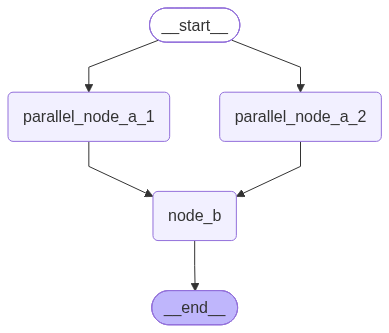

(
│   'tasks',
│   {
│   │   'id': '5348c259-2520-685d-d0e4-79ccb7ee3461',
│   │   'name': 'parallel_node_a_1',
│   │   'input': {'initial_state': '你好'},
│   │   'triggers': ('branch:to:parallel_node_a_1',)
│   }
)

(
│   'tasks',
│   {
│   │   'id': 'dd2036ee-57e8-ec92-2227-bb3760d48335',
│   │   'name': 'parallel_node_a_2',
│   │   'input': {'initial_state': '你好'},
│   │   'triggers': ('branch:to:parallel_node_a_2',)
│   }
)

(
│   'tasks',
│   {
│   │   'id': 'dd2036ee-57e8-ec92-2227-bb3760d48335',
│   │   'name': 'parallel_node_a_2',
│   │   'error': None,
│   │   'result': {'parallel_node_a_2': 'parallel_node_a_2 is running'},
│   │   'interrupts': []
│   }
)

(
│   'tasks',
│   {
│   │   'id': '5348c259-2520-685d-d0e4-79ccb7ee3461',
│   │   'name': 'parallel_node_a_1',
│   │   'error': None,
│   │   'result': {'parallel_node_a_1': 'parallel_node_a_1 is running'},
│   │   'interrupts': []
│   }
)

(
│   'tasks',
│   {
│   │   'id': '7ed6637c-073e-4adb-d604-ea0b7ead9ac0',
│   │   'name': 'node_b',
│   │   'input': {
│   │   │   'initial_state': '你好',
│   │   │   'parallel_node_a_1': 'parallel_node_a_1 is running',
│   │   │   'parallel_node_a_2': 'parallel_node_a_2 is running'
│   │   },
│   │   'triggers': ('branch:to:node_b',)
│   }
)

(
│   'tasks',
│   {
│   │   'id': '7ed6637c-073e-4adb-d604-ea0b7ead9ac0',
│   │   'name': 'node_b',
│   │   'error': None,
│   │   'result': {},
│   │   'interrupts': [{'value': 'hello', 'id': '789460e712be6217878cb88a26692f33'}]
│   }
)

In [31]:
from rich import print as rprint  # 导入 rich 的 print
from rich.pretty import pprint  # 或者使用 pprint
from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END, MessagesState, MessageGraph
from typing import TypedDict, Literal, Sequence, Annotated, Final, Tuple
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
from langchain.tools import tool
from langgraph_runtime_inmem.checkpoint import InMemorySaver
from loguru import logger
import os
# 在所有其他导入之前设置
os.environ["REDIS_URI"] = ""
os.environ["REDIS_URI_CUSTOM"] = ""

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)

class OverAllState(TypedDict):
    initial_state: str
    parallel_node_a_1: str
    parallel_node_a_2: str
    node_b_output: str

def parallel_node_a_1(state:OverAllState)->OverAllState:
    return {
        "parallel_node_a_1": "parallel_node_a_1 is running"
    }

def parallel_node_a_2(state:OverAllState)->OverAllState:
    return {
        "parallel_node_a_2": "parallel_node_a_2 is running"
    }
def node_b(state:OverAllState)->OverAllState:
    interrupt("hello")
    return {
        "node_b_output": "node_b is running"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("parallel_node_a_2", parallel_node_a_2)
builder.add_node("parallel_node_a_1", parallel_node_a_1)
builder.add_node("node_b", node_b)
builder.add_edge(START, "parallel_node_a_1")
builder.add_edge(START, "parallel_node_a_2")
builder.add_edge("parallel_node_a_1", "node_b")
builder.add_edge("parallel_node_a_2", "node_b")
builder.add_edge("node_b", END)
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
display(graph)

config = {"configurable": {"thread_id": "123"}}
try:
    for chunk in graph.stream(
            {"initial_state": "你好"},
            config=config,
            # stream_mode=["checkpoints"]):
            stream_mode=["tasks"],
            # stream_mode=["debug"],
            version="v2"
    ):

        pprint(chunk)
except Exception as e:
    logger.error(e)


In [32]:
from langgraph.types import Command
print("*"*50)
for chunk in graph.stream(
            Command(resume=""),
            config=config,
            stream_mode=["checkpoints"]):
    pprint(chunk)

**************************************************


(
│   'checkpoints',
│   {
│   │   'config': {
│   │   │   'configurable': {
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_id': '1f1a854e-8a90-66f3-8001-d59299227980'
│   │   │   }
│   │   },
│   │   'parent_config': {
│   │   │   'configurable': {
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'checkpoint_id': '1f1a854e-8a4f-6271-8000-53ec9e64016a'
│   │   │   }
│   │   },
│   │   'values': {
│   │   │   'initial_state': '你好',
│   │   │   'parallel_node_a_1': 'parallel_node_a_1 is running',
│   │   │   'parallel_node_a_2': 'parallel_node_a_2 is running'
│   │   },
│   │   'metadata': {'thread_id': '123', 'source': 'loop', 'step': 1, 'parents': {}},
│   │   'next': ['node_b'],
│   │   'tasks': [
│   │   │   {
│   │   │   │   'id': '7ed6637c-073e-4adb-d604-ea0b7ead9ac0',
│   │   │   │   'name': 'node_b',
│   │   │   │   'interrupts': ({'value': 'hello', 'id': '789460e712be6217878cb88a26692f33'},),
│   │   │   │   'state': None
│   │   │   }
│   │   ]
│   }
)

(
│   'checkpoints',
│   {
│   │   'config': {
│   │   │   'configurable': {
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_id': '1f1a854e-8c04-6936-8002-701ad574d3bd'
│   │   │   }
│   │   },
│   │   'parent_config': {
│   │   │   'configurable': {
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_id': '1f1a854e-8a90-66f3-8001-d59299227980'
│   │   │   }
│   │   },
│   │   'values': {
│   │   │   'initial_state': '你好',
│   │   │   'parallel_node_a_1': 'parallel_node_a_1 is running',
│   │   │   'parallel_node_a_2': 'parallel_node_a_2 is running',
│   │   │   'node_b_output': 'node_b is running'
│   │   },
│   │   'metadata': {'source': 'loop', 'step': 2, 'parents': {}},
│   │   'next': [],
│   │   'tasks': []
│   }
)

In [33]:
pprint(list(graph.get_state_history(config=config)))


[
│   StateSnapshot(
│   │   values={
│   │   │   'initial_state': '你好',
│   │   │   'parallel_node_a_1': 'parallel_node_a_1 is running',
│   │   │   'parallel_node_a_2': 'parallel_node_a_2 is running',
│   │   │   'node_b_output': 'node_b is running'
│   │   },
│   │   next=(),
│   │   config={
│   │   │   'configurable': {
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'checkpoint_id': '1f1a854e-8c04-6936-8002-701ad574d3bd'
│   │   │   }
│   │   },
│   │   metadata={'thread_id': '123', 'source': 'loop', 'step': 2, 'parents': {}},
│   │   created_at='2026-09-04T11:36:46.083066+00:00',
│   │   parent_config={
│   │   │   'configurable': {
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'checkpoint_id': '1f1a854e-8a90-66f3-8001-d59299227980'
│   │   │   }
│   │   },
│   │   tasks=(),
│   │   interrupts=()
│   ),
│   StateSnapshot(
│   │   values={
│   │   │   'initial_state': '你好',
│   │   │   'parallel_node_a_1': 'parallel_node_a_1 is running',
│   │   │   'parallel_node_a_2': 'parallel_node_a_2 is running'
│   │   },
│   │   next=('node_b',),
│   │   config={
│   │   │   'configurable': {
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'checkpoint_id': '1f1a854e-8a90-66f3-8001-d59299227980'
│   │   │   }
│   │   },
│   │   metadata={'thread_id': '123', 'source': 'loop', 'step': 1, 'parents': {}},
│   │   created_at='2026-09-04T11:36:45.930657+00:00',
│   │   parent_config={
│   │   │   'configurable': {
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'checkpoint_id': '1f1a854e-8a4f-6271-8000-53ec9e64016a'
│   │   │   }
│   │   },
│   │   tasks=(
│   │   │   PregelTask(
│   │   │   │   id='7ed6637c-073e-4adb-d604-ea0b7ead9ac0',
│   │   │   │   name='node_b',
│   │   │   │   path=('__pregel_pull', 'node_b'),
│   │   │   │   error=None,
│   │   │   │   interrupts=(Interrupt(value='hello', id='789460e712be6217878cb88a26692f33'),),
│   │   │   │   state=None,
│   │   │   │   result={'node_b_output': 'node_b is running'}
│   │   │   ),
│   │   ),
│   │   interrupts=(Interrupt(value='hello', id='789460e712be6217878cb88a26692f33'),)
│   ),
│   StateSnapshot(
│   │   values={'initial_state': '你好'},
│   │   next=('parallel_node_a_2', 'parallel_node_a_1'),
│   │   config={
│   │   │   'configurable': {
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'checkpoint_id': '1f1a854e-8a4f-6271-8000-53ec9e64016a'
│   │   │   }
│   │   },
│   │   metadata={'thread_id': '123', 'source': 'loop', 'step': 0, 'parents': {}},
│   │   created_at='2026-09-04T11:36:45.903909+00:00',
│   │   parent_config={
│   │   │   'configurable': {
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'checkpoint_id': '1f1a854e-8a4a-6af1-bfff-450c2bb936ef'
│   │   │   }
│   │   },
│   │   tasks=(
│   │   │   PregelTask(
│   │   │   │   id='dd2036ee-57e8-ec92-2227-bb3760d48335',
│   │   │   │   name='parallel_node_a_2',
│   │   │   │   path=('__pregel_pull', 'parallel_node_a_2'),
│   │   │   │   error=None,
│   │   │   │   interrupts=(),
│   │   │   │   state=None,
│   │   │   │   result={'parallel_node_a_2': 'parallel_node_a_2 is running'}
│   │   │   ),
│   │   │   PregelTask(
│   │   │   │   id='5348c259-2520-685d-d0e4-79ccb7ee3461',
│   │   │   │   name='parallel_node_a_1',
│   │   │   │   path=('__pregel_pull', 'parallel_node_a_1'),
│   │   │   │   error=None,
│   │   │   │   interrupts=(),
│   │   │   │   state=None,
│   │   │   │   result={'parallel_node_a_1': 'parallel_node_a_1 is running'}
│   │   │   )
│   │   ),
│   │   interrupts=()
│   ),
│   StateSnapshot(
│   │   values={},
│   │   next=('__start__',),
│   │   config={
│   │   │   'configurable': {
│   │   │   │   'thread_id': '123',
│   │   │   │   'checkpoint_ns': '',
│   │   │   │   'checkpoint_id': '1f1a854e-8a4a-6af1-bfff-450c2bb936ef'
│   │   │   }
│   │   },
│ 